In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("(Task) HR_comma_sep.csv")

print(df.head())


   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

In [3]:
X = df.drop('left', axis=1)
y = df['left']


In [4]:
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [6]:
dataset_predictions = model.predict(X)

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(round(accuracy * 100,2), "%")


Accuracy:
78.33 %


In [8]:
sample_employee = [[
    0.45,
    0.80,
    3,
    160,
    3,
    0,
    0,
    0,0,0,0,0,0,0,0,0,
    1,0
]]

sample_prediction = model.predict(sample_employee)

print("\nInitialized Employee Prediction:")

if sample_prediction[0] == 1:
    print("Employee Will Leave")
else:
    print("Employee Will Stay")


Initialized Employee Prediction:
Employee Will Stay


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


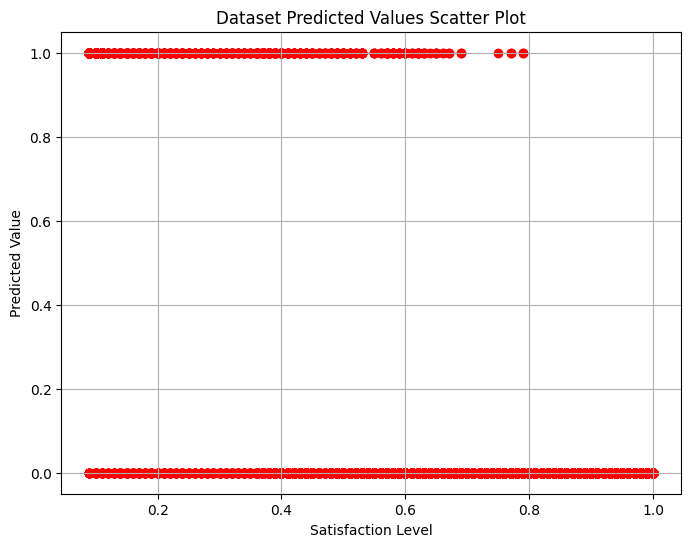

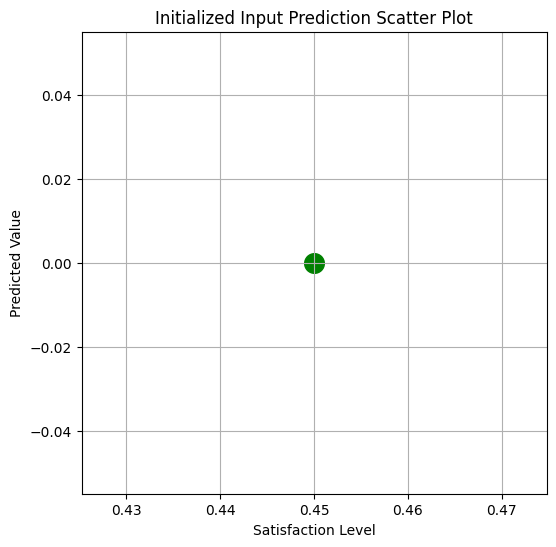

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['satisfaction_level'],
    dataset_predictions,
    color='red'
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Predicted Value")

plt.title("Dataset Predicted Values Scatter Plot")
plt.grid(True)

plt.show()
plt.figure(figsize=(6,6))

plt.scatter(
    sample_employee[0][0],
    sample_prediction[0],
    color='green',
    s=200
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Predicted Value")

plt.title("Initialized Input Prediction Scatter Plot")

plt.grid(True)

plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


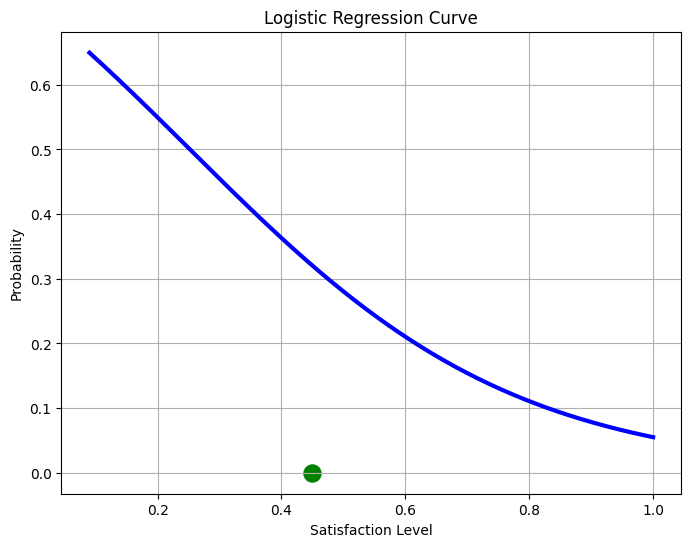

In [10]:
X_graph = df[['satisfaction_level']]

y_graph = df['left']

graph_model = LogisticRegression()

graph_model.fit(X_graph, y_graph)

x_range = np.linspace(
    df.satisfaction_level.min(),
    df.satisfaction_level.max(),
    300
).reshape(-1,1)

y_curve = graph_model.predict_proba(
    x_range
)[:,1]

plt.figure(figsize=(8,6))

plt.plot(
    x_range,
    y_curve,
    color='blue',
    linewidth=3
)
plt.scatter(
    sample_employee[0][0],
    sample_prediction[0],
    color='green',
    s=150
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Probability")
plt.title("Logistic Regression Curve")

plt.grid(True)

plt.show()

In [11]:
import pickle
model_filename='H.pkl'
with open(model_filename,'wb')as file:
  pickle.dump(model,file)
print(f"Pipeline model successfully saved to {model_filename}")

Pipeline model successfully saved to H.pkl


In [1]:
import pickle

model = pickle.load(open("H.pkl", "rb"))

print("Number of features model expects:", model.n_features_in_)
print("Feature names (if available):", model.feature_names_in_)

Number of features model expects: 18
Feature names (if available): ['satisfaction_level' 'last_evaluation' 'number_project'
 'average_montly_hours' 'time_spend_company' 'Work_accident'
 'promotion_last_5years' 'Department_RandD' 'Department_accounting'
 'Department_hr' 'Department_management' 'Department_marketing'
 'Department_product_mng' 'Department_sales' 'Department_support'
 'Department_technical' 'salary_low' 'salary_medium']


In [2]:
model.feature_names_in_

array(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'Department_RandD',
       'Department_accounting', 'Department_hr', 'Department_management',
       'Department_marketing', 'Department_product_mng',
       'Department_sales', 'Department_support', 'Department_technical',
       'salary_low', 'salary_medium'], dtype=object)